In [1]:
from mypytable import MyPyTable
import myutils

mbti = MyPyTable()
mbti.load_from_file("categorical.csv")
mbti = myutils.discretize(mbti, 5)

ie = []
ns = []
tf = []
jp = []

for row in mbti.data:
    ie.append(row[0][0]) # append I for introversion or E for extroversion
    ns.append(row[0][1]) # append N for Intution or S for sensing
    tf.append(row[0][2]) # append T for Thinking or F for feeling
    jp.append(row[0][3]) # append J for Judging or P for perceiving

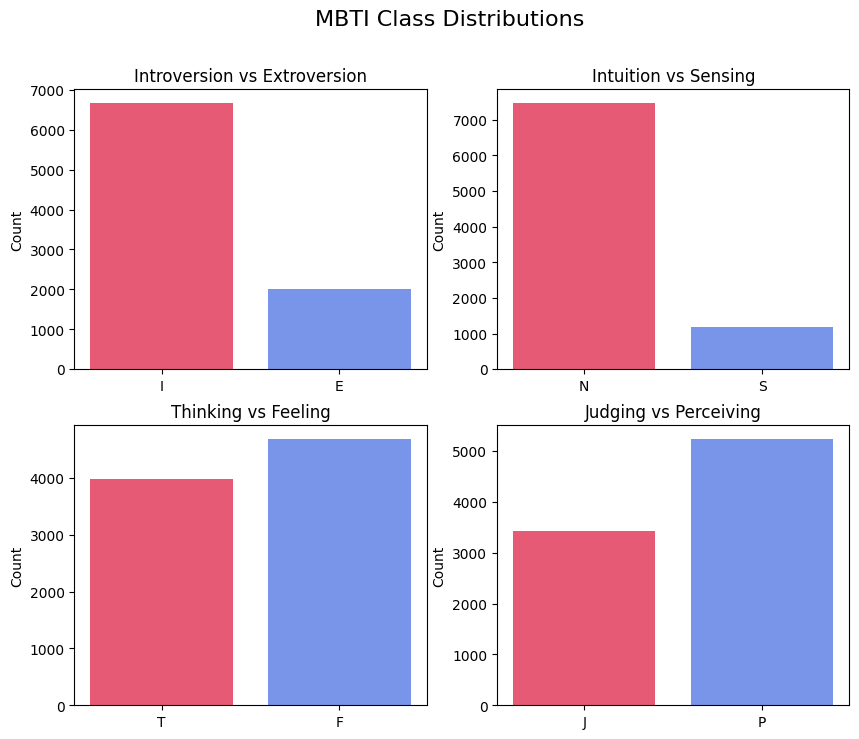

In [2]:
import matplotlib.pyplot as plt

fig, axs = plt.subplots(2, 2, figsize = (10,8))
fig.suptitle("MBTI Class Distributions", fontsize=16)

def create_bar(ax, data, title, labels):
    # Count num of each label
    counts = {}
    
    # Loop through each string value in the data
    for instance in data:
        if instance in counts:
            counts[instance] += 1
        else:
            counts[instance] = 1

    counts_values = [counts.get(label, 0) for label in labels]
    
    # Create bar chart
    bars = ax.bar(labels, counts_values, color=["crimson", "royalblue"], alpha=0.7)

    ax.set_title(title)
    ax.set_ylabel("Count")

create_bar(axs[0, 0], ie, "Introversion vs Extroversion", ["I", "E"])
create_bar(axs[0, 1], ns, "Intuition vs Sensing", ["N", "S"])
create_bar(axs[1, 0], tf, "Thinking vs Feeling", ["T", "F"])
create_bar(axs[1, 1], jp, "Judging vs Perceiving", ["J", "P"])

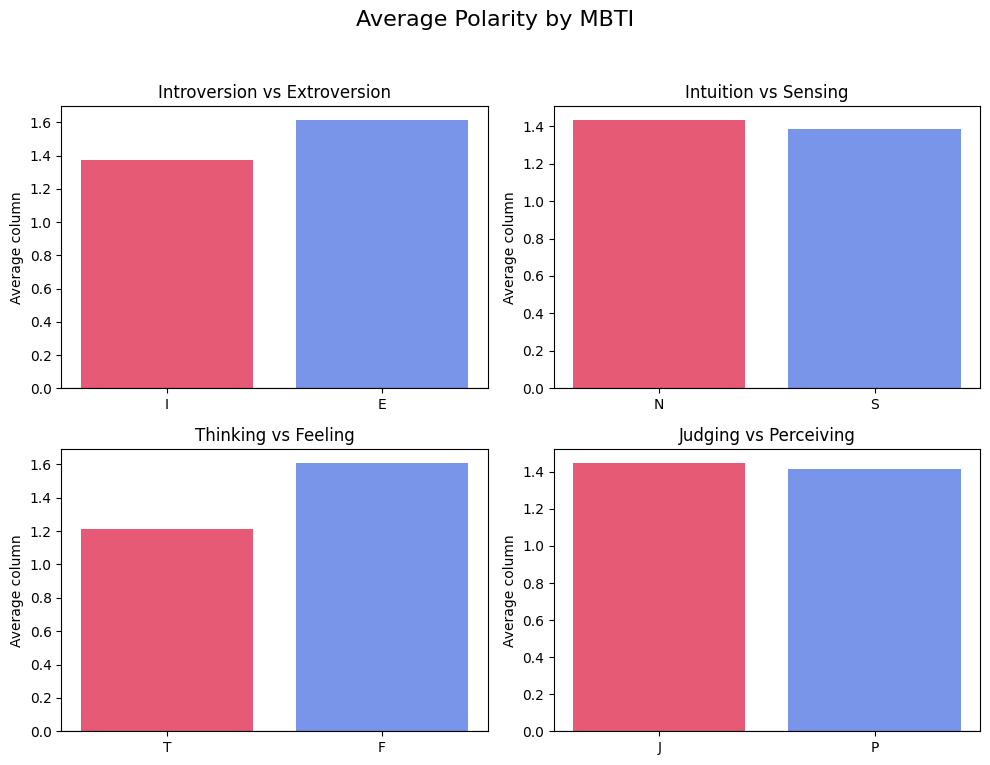

In [3]:
# Graphs for avg column
column = mbti.get_column("Polarity")

# Setup figure
fig, axs = plt.subplots(2, 2, figsize = (10,8))
fig.suptitle("Average Polarity by MBTI", fontsize=16)

def plot_avg_column(ax, labels, column, title, categories):
    """
    Function to plot average column of each differing class. Call this function 4 times, once for each separate binary class

    Arguments:
        ax: Instance of matplotlib.pyplot object
        labels (list of str): List of each binary class occurence. For example, pass in our 'ie' list filled with 'I' or 'E' for introvert/extrovert per row in our dataset.
        column (list of float): List of average column across all 50 tweets from each person.
        title (str): Name of graph.
        categories (list of str): The different binary outcomes for a class. For example, for our ie list we would pass in ["I", "E"].
    """
    counts = {} # stores number of each class (ie. number of introverts vs number of extroverts)
    sums = {} # stores the sum of column fo each unique label (ie. total column for all introverts)

    # Loop through each row
    for i in range(len(labels)):
        label = labels[i]
        score = column[i]

        # Count number of each label
        if label in counts:
            counts[label] += 1
        else:
            counts[label] = 1
        
        # Tally sum of column
        if label in sums:
            sums[label] += score
        else:
            sums[label] = score
    
    # Now calculate average column for each class based on sums and counts
    average_polarities = []
    for cat in categories:
        avg = sums[cat] / counts[cat]
        average_polarities.append(avg)
    
    # Create bar chart
    bars = ax.bar(categories, average_polarities, color=["crimson", "royalblue"], alpha=0.7)

    ax.set_title(title)
    ax.set_ylabel("Average column")
    ax. axhline(0, color="black", linewidth=0.8)


plot_avg_column(axs[0, 0], ie, column, 'Introversion vs Extroversion', ['I', 'E'])
plot_avg_column(axs[0, 1], ns, column, 'Intuition vs Sensing', ['N', 'S'])
plot_avg_column(axs[1, 0], tf, column, 'Thinking vs Feeling', ['T', 'F'])
plot_avg_column(axs[1, 1], jp, column, 'Judging vs Perceiving', ['J', 'P'])


plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

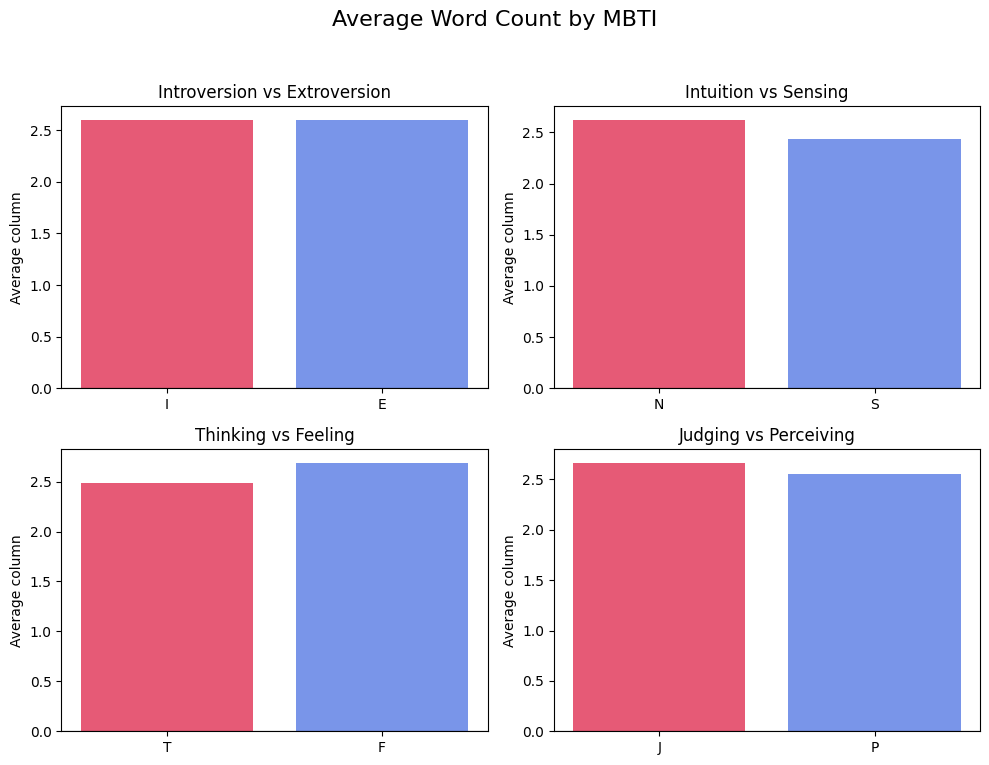

In [10]:
fig, axs = plt.subplots(2, 2, figsize = (10,8))
fig.suptitle("Average Word Count by MBTI", fontsize=16)

# Graphs for avg subjectivity
subjectivity = mbti.get_column("Word Count")



# Plot each dimension
plot_avg_column(axs[0, 0], ie, subjectivity, 'Introversion vs Extroversion', ['I', 'E'])
plot_avg_column(axs[0, 1], ns, subjectivity, 'Intuition vs Sensing', ['N', 'S'])
plot_avg_column(axs[1, 0], tf, subjectivity, 'Thinking vs Feeling', ['T', 'F'])
plot_avg_column(axs[1, 1], jp, subjectivity, 'Judging vs Perceiving', ['J', 'P'])

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

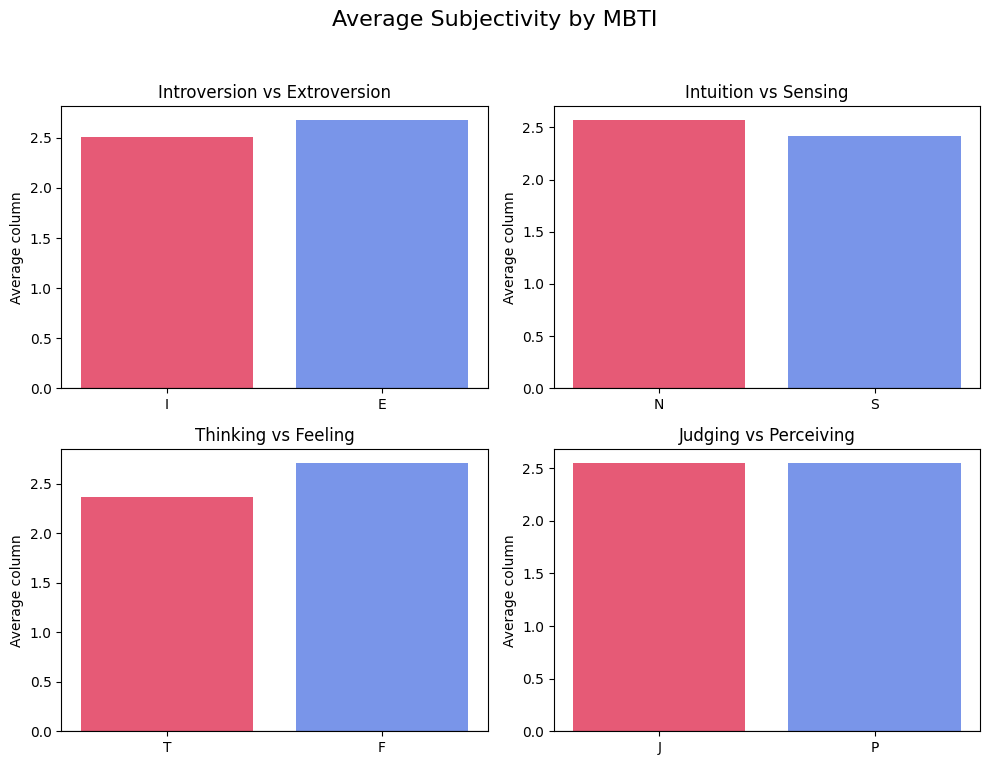

In [4]:
fig, axs = plt.subplots(2, 2, figsize = (10,8))
fig.suptitle("Average Subjectivity by MBTI", fontsize=16)

# Graphs for avg subjectivity
subjectivity = mbti.get_column("Subjectivity")



# Plot each dimension
plot_avg_column(axs[0, 0], ie, subjectivity, 'Introversion vs Extroversion', ['I', 'E'])
plot_avg_column(axs[0, 1], ns, subjectivity, 'Intuition vs Sensing', ['N', 'S'])
plot_avg_column(axs[1, 0], tf, subjectivity, 'Thinking vs Feeling', ['T', 'F'])
plot_avg_column(axs[1, 1], jp, subjectivity, 'Judging vs Perceiving', ['J', 'P'])

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

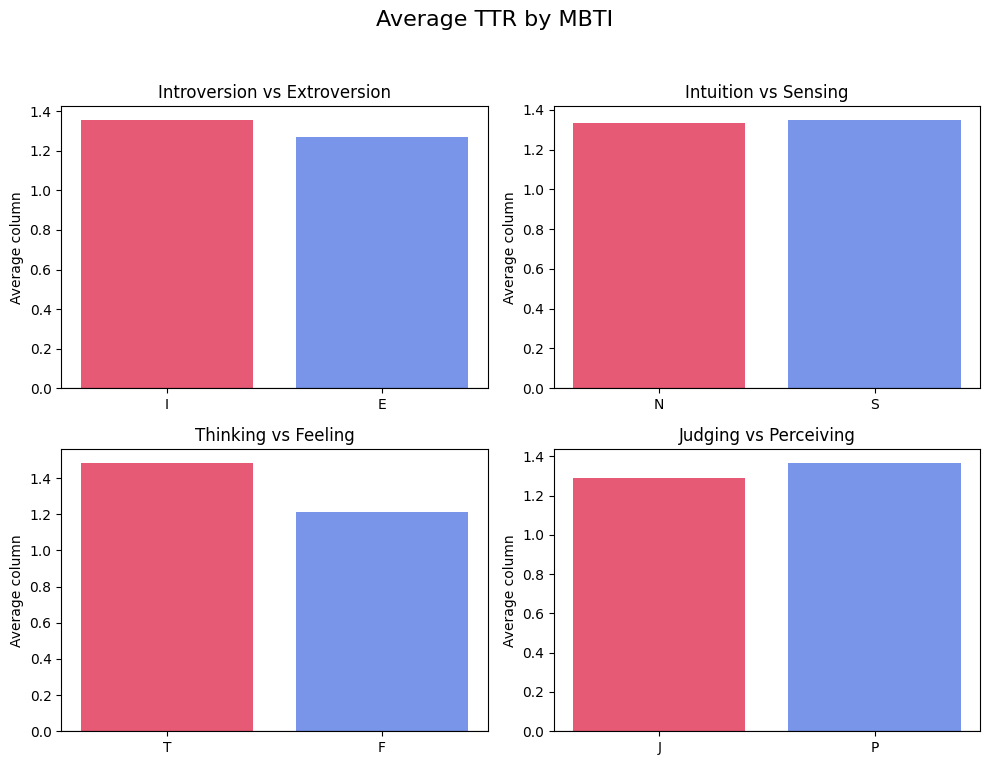

In [5]:
fig, axs = plt.subplots(2, 2, figsize = (10,8))
fig.suptitle("Average TTR by MBTI", fontsize=16)

# Graphs for avg subjectivity
column = mbti.get_column("TTR")



# Plot each dimension
plot_avg_column(axs[0, 0], ie, column, 'Introversion vs Extroversion', ['I', 'E'])
plot_avg_column(axs[0, 1], ns, column, 'Intuition vs Sensing', ['N', 'S'])
plot_avg_column(axs[1, 0], tf, column, 'Thinking vs Feeling', ['T', 'F'])
plot_avg_column(axs[1, 1], jp, column, 'Judging vs Perceiving', ['J', 'P'])

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

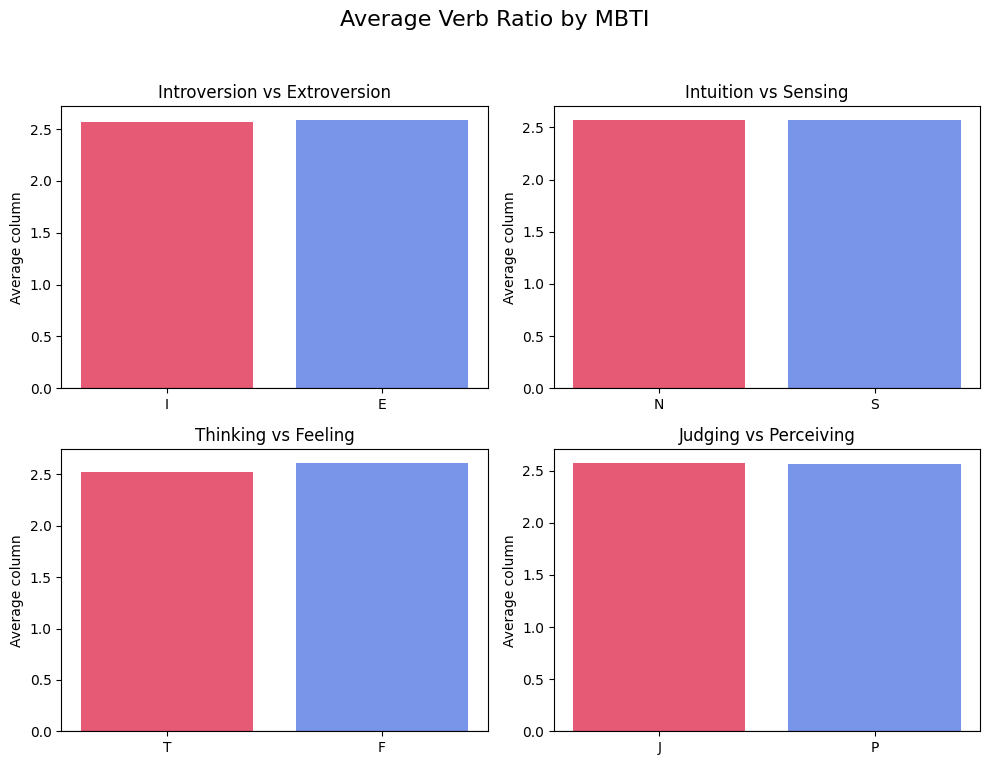

In [6]:
fig, axs = plt.subplots(2, 2, figsize = (10,8))
fig.suptitle("Average Verb Ratio by MBTI", fontsize=16)

# Graphs for avg subjectivity
column = mbti.get_column("Verb Ratio")



# Plot each dimension
plot_avg_column(axs[0, 0], ie, column, 'Introversion vs Extroversion', ['I', 'E'])
plot_avg_column(axs[0, 1], ns, column, 'Intuition vs Sensing', ['N', 'S'])
plot_avg_column(axs[1, 0], tf, column, 'Thinking vs Feeling', ['T', 'F'])
plot_avg_column(axs[1, 1], jp, column, 'Judging vs Perceiving', ['J', 'P'])

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

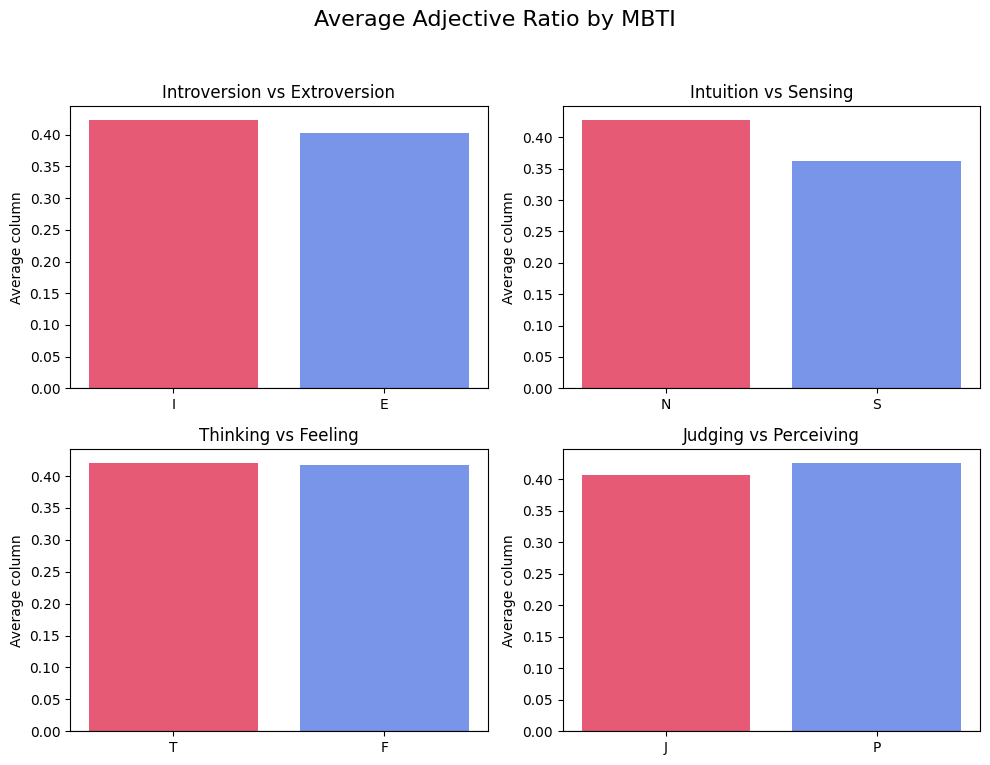

In [7]:
fig, axs = plt.subplots(2, 2, figsize = (10,8))
fig.suptitle("Average Adjective Ratio by MBTI", fontsize=16)

# Graphs for avg subjectivity
column = mbti.get_column("Adjective Ratio")



# Plot each dimension
plot_avg_column(axs[0, 0], ie, column, 'Introversion vs Extroversion', ['I', 'E'])
plot_avg_column(axs[0, 1], ns, column, 'Intuition vs Sensing', ['N', 'S'])
plot_avg_column(axs[1, 0], tf, column, 'Thinking vs Feeling', ['T', 'F'])
plot_avg_column(axs[1, 1], jp, column, 'Judging vs Perceiving', ['J', 'P'])

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

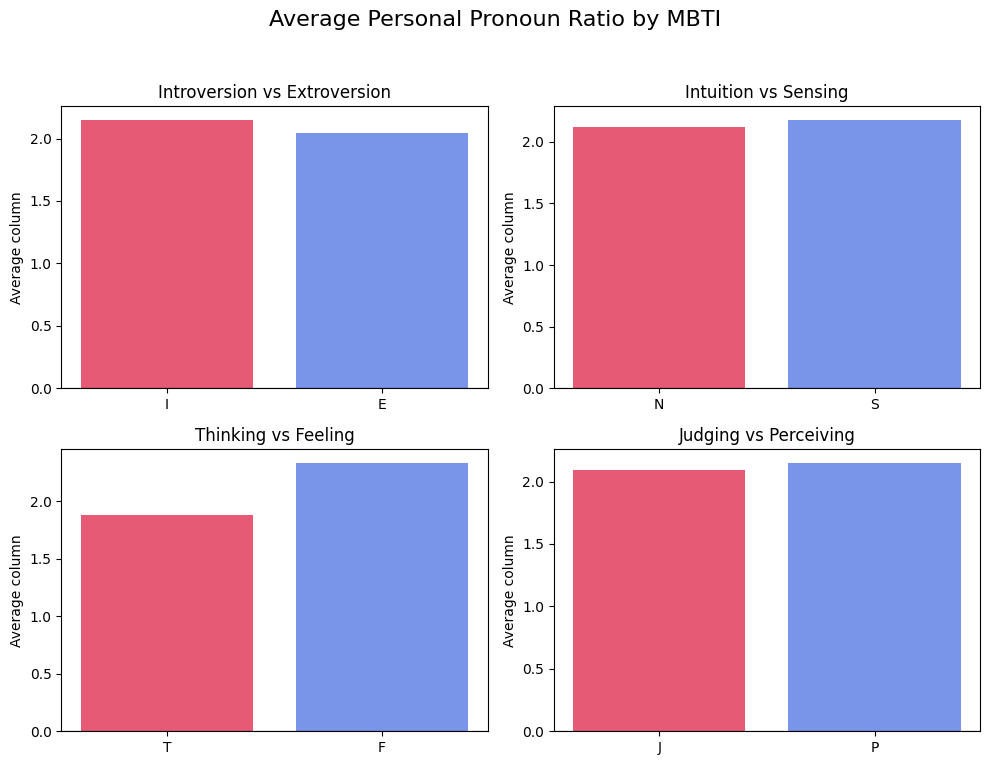

In [8]:
fig, axs = plt.subplots(2, 2, figsize = (10,8))
fig.suptitle("Average Personal Pronoun Ratio by MBTI", fontsize=16)

# Graphs for avg subjectivity
column = mbti.get_column("Personal Pronoun Ratio")



# Plot each dimension
plot_avg_column(axs[0, 0], ie, column, 'Introversion vs Extroversion', ['I', 'E'])
plot_avg_column(axs[0, 1], ns, column, 'Intuition vs Sensing', ['N', 'S'])
plot_avg_column(axs[1, 0], tf, column, 'Thinking vs Feeling', ['T', 'F'])
plot_avg_column(axs[1, 1], jp, column, 'Judging vs Perceiving', ['J', 'P'])

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

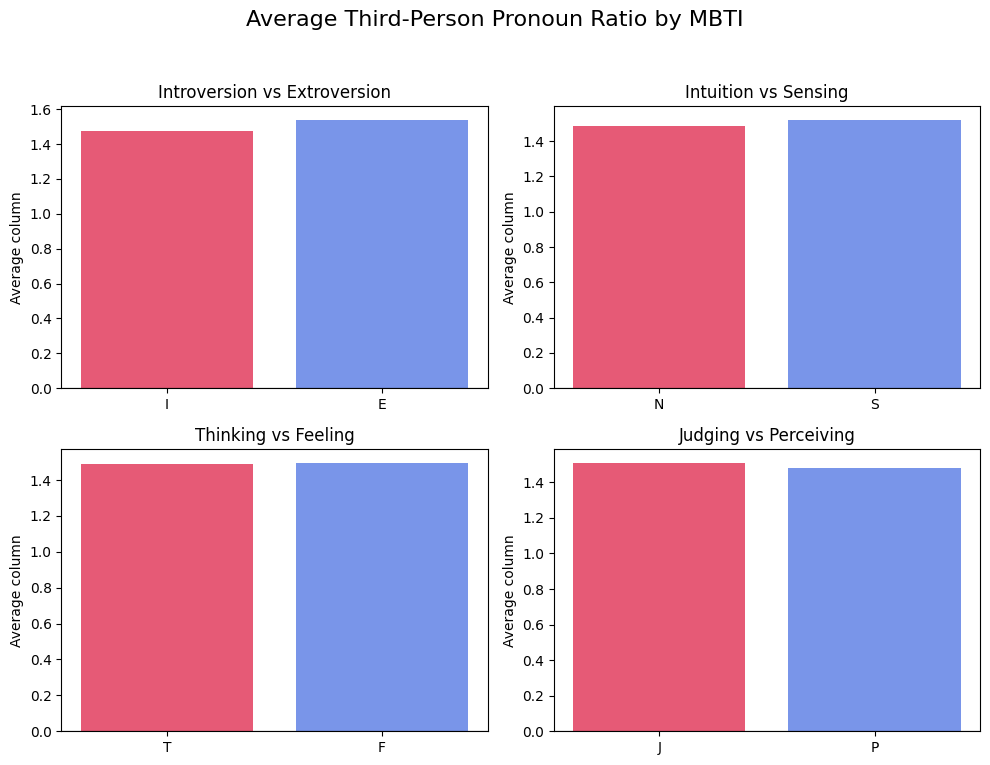

In [9]:
fig, axs = plt.subplots(2, 2, figsize = (10,8))
fig.suptitle("Average Third-Person Pronoun Ratio by MBTI", fontsize=16)

# Graphs for avg subjectivity
column = mbti.get_column("Third-Person Pronoun Ratio")



# Plot each dimension
plot_avg_column(axs[0, 0], ie, column, 'Introversion vs Extroversion', ['I', 'E'])
plot_avg_column(axs[0, 1], ns, column, 'Intuition vs Sensing', ['N', 'S'])
plot_avg_column(axs[1, 0], tf, column, 'Thinking vs Feeling', ['T', 'F'])
plot_avg_column(axs[1, 1], jp, column, 'Judging vs Perceiving', ['J', 'P'])

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()